In [14]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose
from pmdarima import auto_arima
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("train.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45540 entries, 0 to 45539
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   x_coord                    45540 non-null  int64  
 1   y_coord                    45540 non-null  int64  
 2   image_source_x             45342 non-null  object 
 3   water_percentage           45540 non-null  float64
 4   date                       45540 non-null  int64  
 5   year                       45540 non-null  int64  
 6   image_source_y             45540 non-null  object 
 7   inland_aquaculture         45540 non-null  float64
 8   shrimp_rice_farming        45540 non-null  float64
 9   single_rice_cropping       45540 non-null  float64
 10  triple_rice_cropping       45540 non-null  float64
 11  double_rice_cropping_dry   45540 non-null  float64
 12  double_rice_cropping_rain  45540 non-null  float64
 13  others                     45540 non-null  flo

In [5]:
df["date_time"] = pd.to_datetime(df["date_time"])

In [9]:
agg_water = df.groupby("date_time")["water_percentage"].mean()

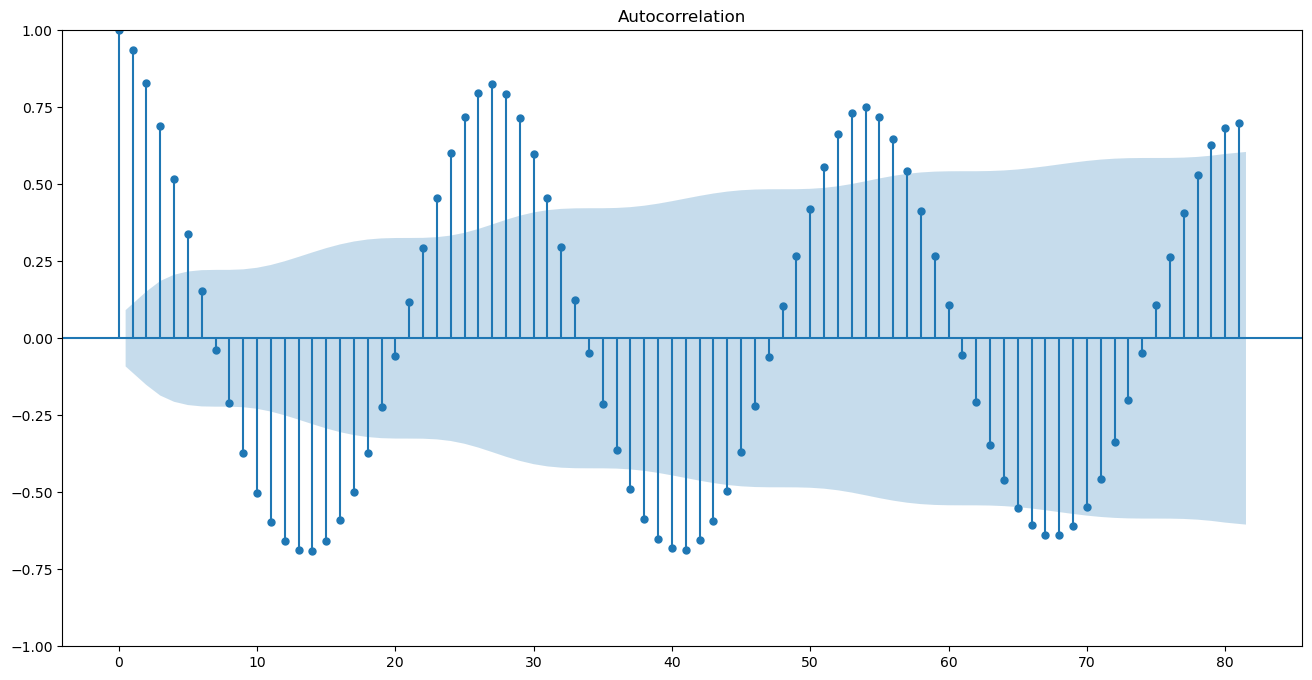

In [39]:
fig, ax = plt.subplots(figsize=(16, 8))  
plot_acf(agg_water, lags=81, alpha=0.05, ax=ax)
plt.savefig("sarima_acf.png")
plt.show()

In [ ]:
The acf plot suggests strong seasonal pattern of s = 27.

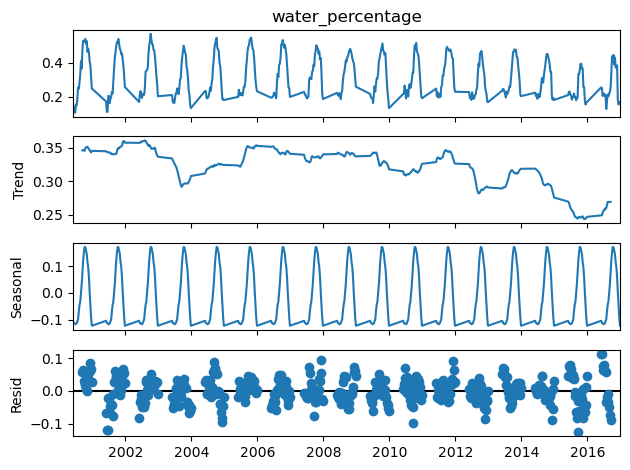

In [40]:
decomposition = seasonal_decompose(agg_water, model="additive", period=27)
decomposition.plot()
plt.savefig("seasonal_decompose.png", dpi=300, bbox_inches="tight")
plt.show()

Value for hyperparamter search: \
p = 0–2 \
d = 0-1 \
q = 0–2 \
P = 0–1 \
D = 0–1 \
Q = 0–1 \
s = 27 \